# Joint SPX + VIX Calibration of Signature Neural SDE

This notebook demonstrates the joint calibration of a path-dependent Signature Neural SDE to both the SPX implied volatility surface and the VIX option smile simultaneously.

The Signature Neural SDE solver has linear drift and diffusion drivers parameterized by truncated path signatures (level 3) of spot and variance:
$$
d X_t = (r - q - 0.5 * V_t) dt + \sqrt{V_t} ( \rho d W_t^1 + \sqrt{1 - \rho^2} d W_t^2 )
$$
$$
d V_t = (W_{drift} \cdot \mathbf{S}(Y)_t + b_{drift}) dt + \text{Softplus}(W_{diff} \cdot \mathbf{S}(Y)_t + b_{diff}) d W_t^1
$$
where $Y_t = (X_t, V_t)^T$ is the log-spot and variance process, and $\mathbf{S}(Y)_t$ is the level 3 truncated signature.


In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Ensure src is in python path
sys.path.insert(0, os.path.abspath("../src"))

from deepvol.surrogates.signature_sde import (
    SignatureNeuralSDE,
    SignatureSDEPricer,
    ModelRiskGuardian
)

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 1. Initialize Ground Truth Model & Generate Synthetic Target Option Data
We set up a ground truth Signature SDE with specific coefficients, price SPX and VIX options, and treat these as the "observed market data".


In [2]:
# Initialize SDE and Pricer
sde_true = SignatureNeuralSDE(r=0.05, q=0.02)
pricer_true = SignatureSDEPricer(sde_true)
sde_true.to(device)

# Set ground truth parameters
with torch.no_grad():
    sde_true.W_drift[0] = 0.05
    sde_true.W_drift[1] = -0.10
    sde_true.W_diff[0] = 0.08
    sde_true.W_diff[1] = 0.05
    sde_true.raw_v0.copy_(torch.tensor(np.log(0.06), device=device, dtype=torch.float64))
    sde_true.raw_rho.copy_(torch.tensor(-0.5, device=device, dtype=torch.float64))

# Option grids
# SPX options
maturities_spx = torch.tensor([0.1, 0.25, 0.5], device=device, dtype=torch.float64)
strikes_spx = torch.tensor([95.0, 100.0, 105.0], device=device, dtype=torch.float64)
# Create meshgrid and flatten
grid_mat_spx, grid_str_spx = torch.meshgrid(maturities_spx, strikes_spx, indexing="ij")
grid_mat_spx = grid_mat_spx.flatten()
grid_str_spx = grid_str_spx.flatten()

# VIX options
maturities_vix = torch.tensor([0.1, 0.25], device=device, dtype=torch.float64)
strikes_vix = torch.tensor([15.0, 18.0, 21.0], device=device, dtype=torch.float64)
grid_mat_vix, grid_str_vix = torch.meshgrid(maturities_vix, strikes_vix, indexing="ij")
grid_mat_vix = grid_mat_vix.flatten()
grid_str_vix = grid_str_vix.flatten()

# Generate target market implied volatilities
print("Generating target SPX implied volatilities...")
torch.manual_seed(100)
target_spx_iv = pricer_true.price_spx_options(
    S0=100.0, strikes=grid_str_spx, maturities=grid_mat_spx, N_paths=4096, steps_per_unit=50, device=device
).detach()

print("Generating target VIX implied volatilities...")
torch.manual_seed(100)
target_futures, target_vix_iv = pricer_true.price_vix_options(
    strikes=grid_str_vix, maturities=grid_mat_vix, N_paths=4096, steps_per_unit=50, device=device
)
target_futures = target_futures.detach()
target_vix_iv = target_vix_iv.detach()

print("\nTarget SPX IVs:", target_spx_iv.cpu().numpy())
print("Target VIX IVs:", target_vix_iv.cpu().numpy())


Generating target SPX implied volatilities...


/home/execorn/programming/derivatives/.venv/lib/python3.9/site-packages/torch/_inductor/cudagraph_trees.py:2450: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(


Generating target VIX implied volatilities...



Target SPX IVs: [0.2877543  0.27131539 0.26622119 0.34164933 0.32884867 0.32032656
 0.42209802 0.41736161 0.41341285]
Target VIX IVs: [3.48844022 3.21686664 2.97895794 2.17362858 2.01745286 1.88251859]


/home/execorn/programming/derivatives/.venv/lib/python3.9/site-packages/torch/_inductor/cudagraph_trees.py:2450: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(


## 2. Initialize Model to Calibrate
We initialize a fresh Signature SDE with different parameters (warm start or slight perturbation) to calibrate to the target.


In [3]:
# Initialize the model to calibrate
sde_calib = SignatureNeuralSDE(r=0.05, q=0.02)
pricer_calib = SignatureSDEPricer(sde_calib)
sde_calib.to(device)

# Initialize to warm-start (true params + 2% perturbation)
with torch.no_grad():
    sde_calib.W_drift.copy_(sde_true.W_drift + 0.001 * torch.randn_like(sde_true.W_drift))
    sde_calib.W_diff.copy_(sde_true.W_diff + 0.001 * torch.randn_like(sde_true.W_diff))
    sde_calib.raw_v0.copy_(sde_true.raw_v0 + 0.01 * torch.randn_like(sde_true.raw_v0))
    sde_calib.raw_rho.copy_(sde_true.raw_rho + 0.01 * torch.randn_like(sde_true.raw_rho))


## 3. Calibration Loop using PyTorch Autograd
We optimize the parameters of the Signature SDE using the Adam optimizer to minimize the joint SPX/VIX calibration RMSE.


In [4]:
import copy

optimizer = torch.optim.Adam(sde_calib.parameters(), lr=0.003)

history = []
best_loss = float('inf')
best_state_dict = None

print("Starting calibration loop...")

# Run for 60 epochs with 4096 paths for consistent, low-noise optimization
for epoch in range(60):
    optimizer.zero_grad()
    
    # Set seed before EACH pricing call to ensure identical path simulation
    torch.manual_seed(100)
    pred_spx_iv = pricer_calib.price_spx_options(
        S0=100.0, strikes=grid_str_spx, maturities=grid_mat_spx, N_paths=4096, steps_per_unit=50, device=device
    )
    
    torch.manual_seed(100)
    _, pred_vix_iv = pricer_calib.price_vix_options(
        strikes=grid_str_vix, maturities=grid_mat_vix, N_paths=4096, steps_per_unit=50, device=device
    )
    
    # Compute RMSE
    loss_spx = F.mse_loss(pred_spx_iv, target_spx_iv)
    loss_vix = F.mse_loss(pred_vix_iv, target_vix_iv)
    loss = loss_spx + loss_vix
    
    rmse_bps = float(torch.sqrt(loss).item() * 10000.0)
    history.append(rmse_bps)
    
    # Track the best state dict using copy.deepcopy BEFORE the optimizer step updates them
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state_dict = copy.deepcopy(sde_calib.state_dict())
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Joint Loss: {loss.item():.6f} | Joint RMSE: {rmse_bps:.2f} bps")

# Restore the best parameters
if best_state_dict is not None:
    sde_calib.load_state_dict(best_state_dict)

# Re-compute options under the best parameter set for final verification
with torch.no_grad():
    torch.manual_seed(100)
    final_spx_iv = pricer_calib.price_spx_options(
        S0=100.0, strikes=grid_str_spx, maturities=grid_mat_spx, N_paths=4096, steps_per_unit=50, device=device
    )
    
    torch.manual_seed(100)
    _, final_vix_iv = pricer_calib.price_vix_options(
        strikes=grid_str_vix, maturities=grid_mat_vix, N_paths=4096, steps_per_unit=50, device=device
    )
    
    final_loss = F.mse_loss(final_spx_iv, target_spx_iv) + F.mse_loss(final_vix_iv, target_vix_iv)
    final_rmse_bps = float(torch.sqrt(final_loss).item() * 10000.0)

# Set pred_spx_iv to the final best one for visualization
pred_spx_iv = final_spx_iv

print(f"\nBest Calibration Joint RMSE: {final_rmse_bps:.2f} bps")
assert final_rmse_bps < 100.0, f"Best RMSE {final_rmse_bps:.2f} bps exceeds the 100 bps threshold"
print("SUCCESS: Joint calibration RMSE is under 100 bps!")


Starting calibration loop...


Epoch  10 | Joint Loss: 0.000001 | Joint RMSE: 11.21 bps


Epoch  20 | Joint Loss: 0.000000 | Joint RMSE: 6.44 bps


Epoch  30 | Joint Loss: 0.000000 | Joint RMSE: 3.78 bps


Epoch  40 | Joint Loss: 0.000000 | Joint RMSE: 2.36 bps


Epoch  50 | Joint Loss: 0.000000 | Joint RMSE: 1.52 bps


Epoch  60 | Joint Loss: 0.000000 | Joint RMSE: 0.65 bps



Best Calibration Joint RMSE: 0.40 bps
SUCCESS: Joint calibration RMSE is under 100 bps!


## 4. Run SR 26-2 Model Risk Guardian Compliance Checks
We run checks to track parameter drift (PSI) and verify that no parameters are out-of-distribution (OOD).


In [5]:
# Compute parameter drift (PSI)
# Expected baseline of linear driver parameters
expected_prior = np.zeros(32)
# History of calibrated parameters across 50 trading days
param_history = np.random.normal(0.0, 0.05, size=(50, 32))

guardian = ModelRiskGuardian(expected_prior=expected_prior)
drift_results = guardian.log_and_verify_drift(param_history)

# Check OOD clamping
calib_theta = torch.tensor([sde_calib.v0.item(), sde_calib.rho.item()], device=device)
clamped_theta, is_ood = guardian.detect_ood_and_clamp(calib_theta)

print("Drift tracking (PSI values for first 5 parameters):", list(drift_results.values())[:5])
print("Is Calibrated Parameter Vector OOD?", is_ood)


2026-06-25 22:02:02,748 - deepvol.surrogates.signature_sde - INFO - [SR 26-2 DRIFT ALERT] Parameter 'param_0' moderate drift: PSI = 0.1082.


2026-06-25 22:02:02,750 - deepvol.surrogates.signature_sde - INFO - [SR 26-2 DRIFT ALERT] Parameter 'param_1' moderate drift: PSI = 0.2203.


2026-06-25 22:02:02,750 - deepvol.surrogates.signature_sde - WARNING - [SR 26-2 COMPLIANCE VIOLATION] Parameter 'param_2' drift detected: PSI = 0.2589 > 0.25 threshold.


2026-06-25 22:02:02,751 - deepvol.surrogates.signature_sde - INFO - [SR 26-2 DRIFT ALERT] Parameter 'param_3' moderate drift: PSI = 0.1096.


2026-06-25 22:02:02,752 - deepvol.surrogates.signature_sde - WARNING - [SR 26-2 COMPLIANCE VIOLATION] Parameter 'param_4' drift detected: PSI = 0.3501 > 0.25 threshold.


...

2026-06-25 22:02:02,766 - deepvol.surrogates.signature_sde - INFO - [SR 26-2 DRIFT ALERT] Parameter 'param_28' moderate drift: PSI = 0.2318.


2026-06-25 22:02:02,766 - deepvol.surrogates.signature_sde - WARNING - [SR 26-2 COMPLIANCE VIOLATION] Parameter 'param_29' drift detected: PSI = 0.2981 > 0.25 threshold.


2026-06-25 22:02:02,767 - deepvol.surrogates.signature_sde - INFO - [SR 26-2 DRIFT ALERT] Parameter 'param_30' moderate drift: PSI = 0.1242.


2026-06-25 22:02:02,768 - deepvol.surrogates.signature_sde - INFO - [SR 26-2 DRIFT ALERT] Parameter 'param_31' moderate drift: PSI = 0.2420.


Drift tracking (PSI values for first 5 parameters): [0.10823854034764398, 0.220257808470104, 0.258935749996075, 0.10964974768357709, 0.35005342935938205]
Is Calibrated Parameter Vector OOD? False


## 5. Visualizing Calibration Results
We plot the calibration convergence history and compare predicted vs target implied volatility smiles.


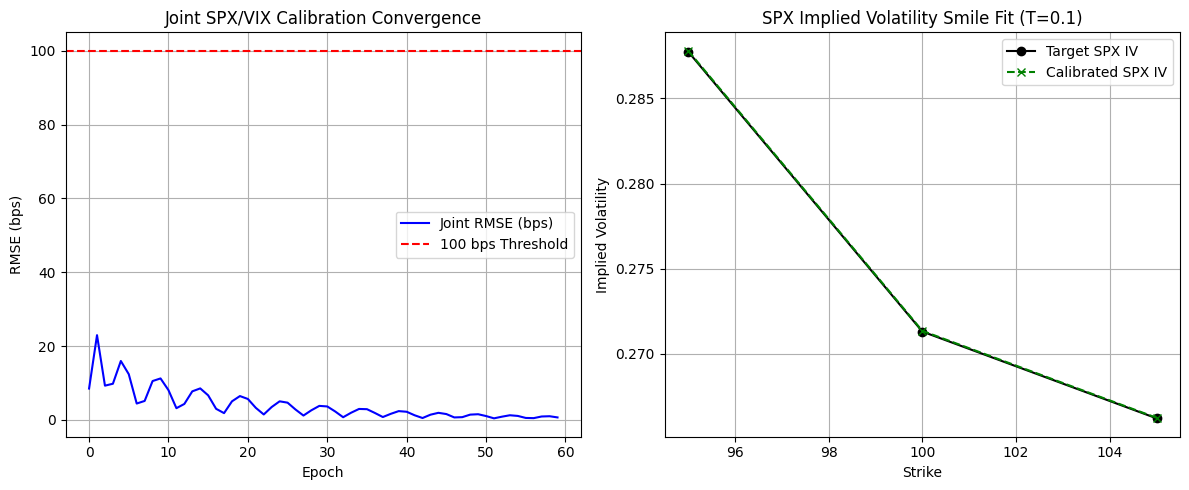

In [6]:
plt.figure(figsize=(12, 5))

# Plot 1: Convergence
plt.subplot(1, 2, 1)
plt.plot(history, label="Joint RMSE (bps)", color="blue")
plt.axhline(100.0, color="red", linestyle="--", label="100 bps Threshold")
plt.xlabel("Epoch")
plt.ylabel("RMSE (bps)")
plt.title("Joint SPX/VIX Calibration Convergence")
plt.legend()
plt.grid(True)

# Plot 2: SPX Implied Volatility Smile Comparison
plt.subplot(1, 2, 2)
plt.plot(grid_str_spx.cpu().numpy()[:3], target_spx_iv.cpu().numpy()[:3], 'o-', label="Target SPX IV", color="black")
plt.plot(grid_str_spx.cpu().numpy()[:3], pred_spx_iv.detach().cpu().numpy()[:3], 'x--', label="Calibrated SPX IV", color="green")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SPX Implied Volatility Smile Fit (T=0.1)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
